# Wisconsin Breast Cancer Classification

This notebook builds a complete pipeline for binary classification of breast tumours with SHAP eXplainable Artificial Intelligence as *malignant* (0) or *benign* (1) using the classic **Wisconsin Breast Cancer Dataset**.


## Environment Setup



In [ ]:
!pip install shap xgboost torch torchvision scikit-learn matplotlib seaborn ipywidgets --quiet

## Imports




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from IPython.display import display
import ipywidgets as widgets

shap.initjs()

## Data Loading & Initial


In [ ]:
#Load datasets & Classes
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
print("Classes:", data.target_names)

X.head()

Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
#Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Exploratory Data Analysis (EDA)




In [ ]:
# Check missing values
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### Class distribution

Imbalanced classes cause models to be biased toward the majority. We check the ratio before training.


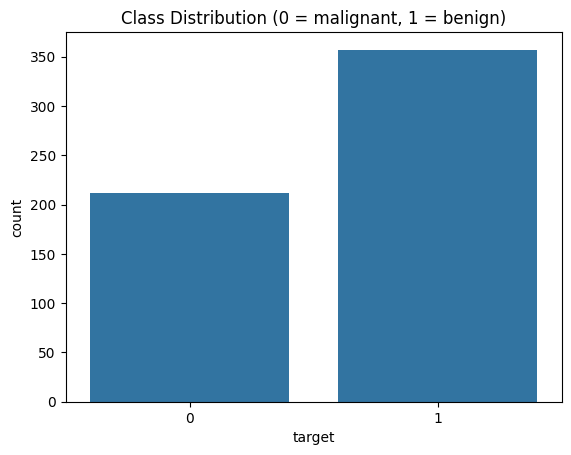

,proportion
target,
1,0.627417
0,0.372583


In [ ]:
# Check data Imbalance
sns.countplot(x=df['target'])
plt.title("Class Distribution (0 = malignant, 1 = benign)")
plt.show()

df['target'].value_counts(normalize=True)



## Pre-processing & Train / Test Split



In [ ]:
#Split to train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## PyTorch MLP

In [ ]:
#Model Architecture
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

def train_mlp(X_train, y_train, X_val, y_val, patience=10, epochs=100):
    model = MLP(X_train.shape[1])

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=5,
        factor=0.5
    )

    best_loss = np.inf
    early_stop_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "accuracy": [],
        "auc": []
    }

    for epoch in range(epochs):

        # Train
        model.train()
        optimizer.zero_grad()

        outputs = model(torch.FloatTensor(X_train)).squeeze()
        loss = criterion(outputs, torch.FloatTensor(y_train.values))

        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(torch.FloatTensor(X_val)).squeeze()
            val_loss = criterion(
                val_outputs,
                torch.FloatTensor(y_val.values)
            )

            probs = torch.sigmoid(val_outputs).numpy()
            preds = (probs > 0.5).astype(int)

            acc = accuracy_score(y_val, preds)
            auc = roc_auc_score(y_val, probs)

        scheduler.step(val_loss)

        # metrics
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())
        history["accuracy"].append(acc)
        history["auc"].append(auc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {loss.item():.4f}")
        print(f"Validation Loss: {val_loss.item():.4f}")
        print(f"Accuracy: {acc:.4f}, ROC-AUC: {auc:.4f}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        print("--------------------")

        # Early Stopping
        if val_loss.item() < best_loss:
            best_loss = val_loss.item()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n Early stopping triggered at epoch {epoch+1}")
            break

    return model, history

### Train the MLP




In [ ]:
# History
model, history = train_mlp(
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    patience=10,
    epochs=200
)

Epoch 1/200
Training Loss: 0.7085
Validation Loss: 0.6924
Accuracy: 0.6316, ROC-AUC: 0.1882
Learning Rate: 0.001000
--------------------
Epoch 2/200
Training Loss: 0.6971
Validation Loss: 0.6826
Accuracy: 0.6316, ROC-AUC: 0.3221
Learning Rate: 0.001000
--------------------
Epoch 3/200
Training Loss: 0.6860
Validation Loss: 0.6728
Accuracy: 0.6316, ROC-AUC: 0.5470
Learning Rate: 0.001000
--------------------
Epoch 4/200
Training Loss: 0.6751
Validation Loss: 0.6630
Accuracy: 0.6316, ROC-AUC: 0.7563
Learning Rate: 0.001000
--------------------
Epoch 5/200
Training Loss: 0.6644
Validation Loss: 0.6533
Accuracy: 0.6404, ROC-AUC: 0.8935
Learning Rate: 0.001000
--------------------
Epoch 6/200
Training Loss: 0.6537
Validation Loss: 0.6437
Accuracy: 0.6491, ROC-AUC: 0.9484
Learning Rate: 0.001000
--------------------
Epoch 7/200
Training Loss: 0.6431
Validation Loss: 0.6342
Accuracy: 0.6842, ROC-AUC: 0.9742
Learning Rate: 0.001000
--------------------
Epoch 8/200
Training Loss: 0.6325
Validat

### Training curves




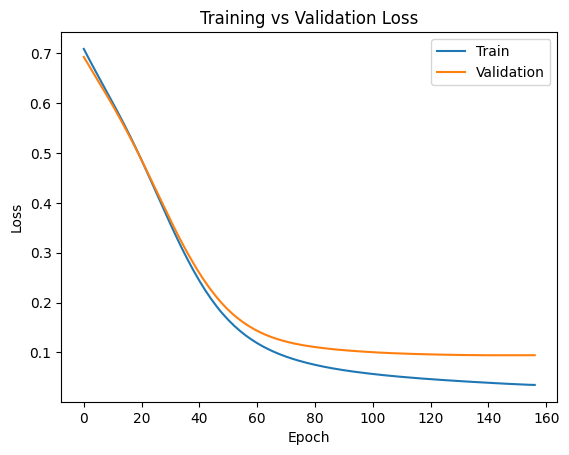

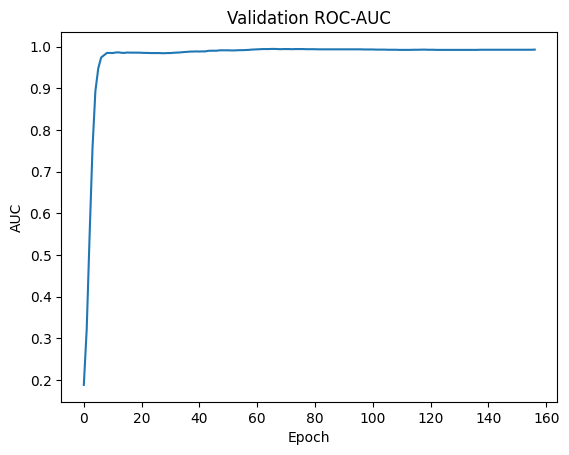

In [ ]:
plt.figure()
plt.plot(history["train_loss"])
plt.plot(history["val_loss"])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()


plt.figure()
plt.plot(history["auc"])
plt.title("Validation ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.show()

## Classical ML Models



In [ ]:
#Define multiple model
def get_model(name):
    if name == "RandomForest":
        return RandomForestClassifier()
    elif name == "SVM":
        return SVC(probability=True)
    elif name == "XGBoost":
        return XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    elif name == "DecisionTree":
        return DecisionTreeClassifier()
    elif name == "MLP":
        return "MLP"

### Train-and-evaluate


In [ ]:
#Models training & evaluation
def train_and_evaluate(model_name):
    print(f"\nTraining {model_name}...\n")

    if model_name == "MLP":
        model, history = train_mlp(
            X_train_scaled,
            y_train,
            X_test_scaled,
            y_test
        )

        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(
                model(torch.FloatTensor(X_test_scaled))
            ).numpy().flatten()

        preds = (probs > 0.5).astype(int)

        accuracy = accuracy_score(y_test, preds)

    else:
        model = get_model(model_name)
        model.fit(X_train_scaled, y_train)

        preds = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, preds)

    print("Accuracy:", accuracy)
    print(classification_report(y_test, preds))

    return model

### MLP sanity check




In [ ]:
train_and_evaluate(model_name="MLP")


Training MLP...

Epoch 1/200
Training Loss: 0.7000
Validation Loss: 0.6828
Accuracy: 0.6404, ROC-AUC: 0.7120
Learning Rate: 0.001000
--------------------
Epoch 2/200
Training Loss: 0.6878
Validation Loss: 0.6722
Accuracy: 0.7632, ROC-AUC: 0.8492
Learning Rate: 0.001000
--------------------
Epoch 3/200
Training Loss: 0.6760
Validation Loss: 0.6616
Accuracy: 0.8684, ROC-AUC: 0.9170
Learning Rate: 0.001000
--------------------
Epoch 4/200
Training Loss: 0.6645
Validation Loss: 0.6510
Accuracy: 0.9298, ROC-AUC: 0.9507
Learning Rate: 0.001000
--------------------
Epoch 5/200
Training Loss: 0.6531
Validation Loss: 0.6404
Accuracy: 0.9298, ROC-AUC: 0.9643
Learning Rate: 0.001000
--------------------
Epoch 6/200
Training Loss: 0.6417
Validation Loss: 0.6297
Accuracy: 0.9298, ROC-AUC: 0.9712
Learning Rate: 0.001000
--------------------
Epoch 7/200
Training Loss: 0.6304
Validation Loss: 0.6190
Accuracy: 0.9386, ROC-AUC: 0.9769
Learning Rate: 0.001000
--------------------
Epoch 8/200
Training Lo

MLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

### Unified prediction




In [ ]:
def get_predictions(model, model_name):
    if model_name == "MLP":
        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(
                model(torch.FloatTensor(X_test_scaled))
            ).numpy().flatten()

        preds = (probs > 0.5).astype(int)
    else:
        probs = model.predict_proba(X_test_scaled)[:, 1]
        preds = model.predict(X_test_scaled)

    return preds, probs

## Model Comparison — Accuracy & AUC



In [ ]:
results = []

# Using models_to_compare
models_to_evaluate = [
    "RandomForest",
    "SVM",
    "XGBoost",
    "DecisionTree",
    "MLP"
]

for name in models_to_evaluate:
    print(f"Evaluating {name}...")

    # Train the model (handling MLP separately as it's a custom torch model)
    if name == "MLP":
        model, _ = train_mlp(X_train_scaled, y_train, X_test_scaled, y_test, epochs=50) # Reduced epochs for faster evaluation here
    else:
        model = get_model(name)
        model.fit(X_train_scaled, y_train)

    # Get predictions and probabilities using the defined function
    preds, probs = get_predictions(model, name)

    # Calculate metrics
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    results.append([name, acc, auc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
display(results_df.sort_values("Accuracy", ascending=False))

Evaluating RandomForest...
Evaluating SVM...
Evaluating XGBoost...
Evaluating DecisionTree...
Evaluating MLP...
Epoch 1/50
Training Loss: 0.6855
Validation Loss: 0.6672
Accuracy: 0.6316, ROC-AUC: 0.5552
Learning Rate: 0.001000
--------------------
Epoch 2/50
Training Loss: 0.6729
Validation Loss: 0.6559
Accuracy: 0.6404, ROC-AUC: 0.7603
Learning Rate: 0.001000
--------------------
Epoch 3/50
Training Loss: 0.6607
Validation Loss: 0.6450
Accuracy: 0.6404, ROC-AUC: 0.8859
Learning Rate: 0.001000
--------------------
Epoch 4/50
Training Loss: 0.6488
Validation Loss: 0.6343
Accuracy: 0.6404, ROC-AUC: 0.9398
Learning Rate: 0.001000
--------------------
Epoch 5/50
Training Loss: 0.6372
Validation Loss: 0.6238
Accuracy: 0.6754, ROC-AUC: 0.9600
Learning Rate: 0.001000
--------------------
Epoch 6/50
Training Loss: 0.6258
Validation Loss: 0.6133
Accuracy: 0.7018, ROC-AUC: 0.9676
Learning Rate: 0.001000
--------------------
Epoch 7/50
Training Loss: 0.6144
Validation Loss: 0.6029
Accuracy: 0.719

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:06:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Epoch 24/50
Training Loss: 0.4108
Validation Loss: 0.4121
Accuracy: 0.9474, ROC-AUC: 0.9798
Learning Rate: 0.001000
--------------------
Epoch 25/50
Training Loss: 0.3982
Validation Loss: 0.4003
Accuracy: 0.9474, ROC-AUC: 0.9802
Learning Rate: 0.001000
--------------------
Epoch 26/50
Training Loss: 0.3857
Validation Loss: 0.3885
Accuracy: 0.9386, ROC-AUC: 0.9808
Learning Rate: 0.001000
--------------------
Epoch 27/50
Training Loss: 0.3732
Validation Loss: 0.3769
Accuracy: 0.9386, ROC-AUC: 0.9812
Learning Rate: 0.001000
--------------------
Epoch 28/50
Training Loss: 0.3609
Validation Loss: 0.3654
Accuracy: 0.9386, ROC-AUC: 0.9808
Learning Rate: 0.001000
--------------------
Epoch 29/50
Training Loss: 0.3488
Validation Loss: 0.3540
Accuracy: 0.9386, ROC-AUC: 0.9812
Learning Rate: 0.001000
--------------------
Epoch 30/50
Training Loss: 0.3368
Validation Loss: 0.3428
Accuracy: 0.9298, ROC-AUC: 0.9815
Learning Rate: 0.001000
--------------------
Epoch 31/50
Training Loss: 0.3251
Validat

,Model,Accuracy,ROC-AUC
1,SVM,0.982456,0.995040
2,XGBoost,0.956140,0.990079
0,RandomForest,0.947368,0.991071
4,MLP,0.947368,0.990741
3,DecisionTree,0.903509,0.903770


### Per-model confusion matrices




In [ ]:
for model_name in models:
    preds, _ = get_predictions(model, model_name, X_test_scaled)
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## SHAP Explainability




In [ ]:
def explain_with_shap(model, model_name):
    print("\nGenerating SHAP explanations...\n")

    # Use scaled data consistently
    X_background = X_train_scaled[:100]
    X_sample = X_test_scaled[:50]

    # Convert to DataFrame with feature names
    X_sample_df = pd.DataFrame(
        X_sample,
        columns=X.columns
    )

    if model_name == "MLP":
        model.eval()

        explainer = shap.DeepExplainer(
            model,
            torch.FloatTensor(X_background)
        )

        shap_values = explainer.shap_values(
            torch.FloatTensor(X_sample)
        )

        # DeepExplainer returns list for binary classification
        if isinstance(shap_values, list):
            shap_values = shap_values[0]

    elif model_name in ["RandomForest", "DecisionTree", "XGBoost"]:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

        # For binary classification take class 1
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

    else:  # SVM
        explainer = shap.KernelExplainer(
            model.predict_proba,
            X_background
        )
        shap_values = explainer.shap_values(X_sample)

        if isinstance(shap_values, list):
            shap_values = shap_values[1]

    # Ensure shape consistency
    shap_values = np.array(shap_values)

    print("SHAP shape:", shap_values.shape)
    print("Feature shape:", X_sample_df.shape)

    shap.summary_plot(
        shap_values,
        X_sample_df,
        feature_names=X.columns
    )

Dropdown(description='Model:', options=('RandomForest', 'SVM', 'XGBoost', 'DecisionTree', 'MLP'), value='Rando…

Button(description='Train & Explain', style=ButtonStyle())


Training SVM...

Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Generating SHAP explanations...



  0%|          | 0/50 [00:00<?, ?it/s]

SHAP shape: (50, 30, 2)
Feature shape: (50, 30)


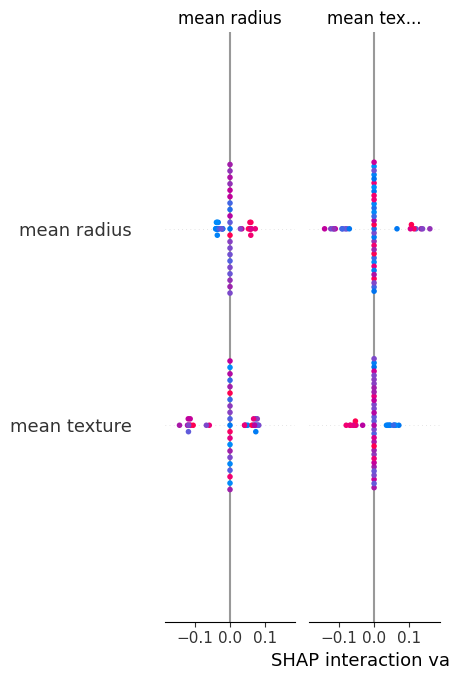

In [ ]:
model_dropdown = widgets.Dropdown(
    options=["RandomForest", "SVM", "XGBoost", "DecisionTree", "MLP"],
    description="Model:"
)

run_button = widgets.Button(description="Train & Explain")

def on_click(b):
    model_name = model_dropdown.value
    model = train_and_evaluate(model_name)
    explain_with_shap(model, model_name)

run_button.on_click(on_click)

display(model_dropdown, run_button)

### Batch SHAP for all classical models




========== RandomForest ==========


Training RandomForest...

Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Generating SHAP explanations...

SHAP shape: (50, 30, 2)
Feature shape: (50, 30)


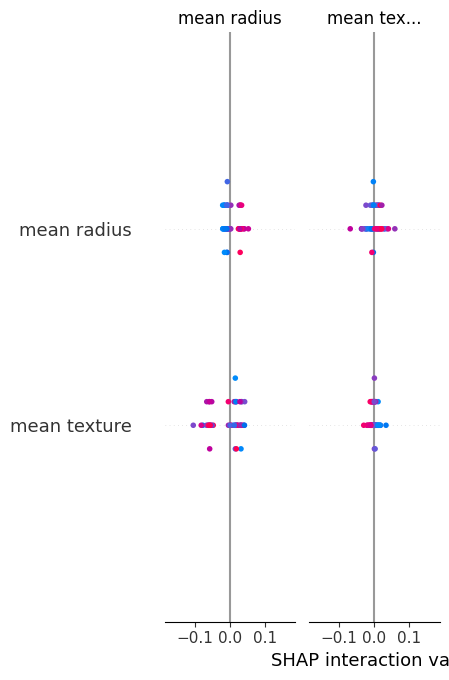


========== SVM ==========


Training SVM...

Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Generating SHAP explanations...



  0%|          | 0/50 [00:00<?, ?it/s]

SHAP shape: (50, 30, 2)
Feature shape: (50, 30)


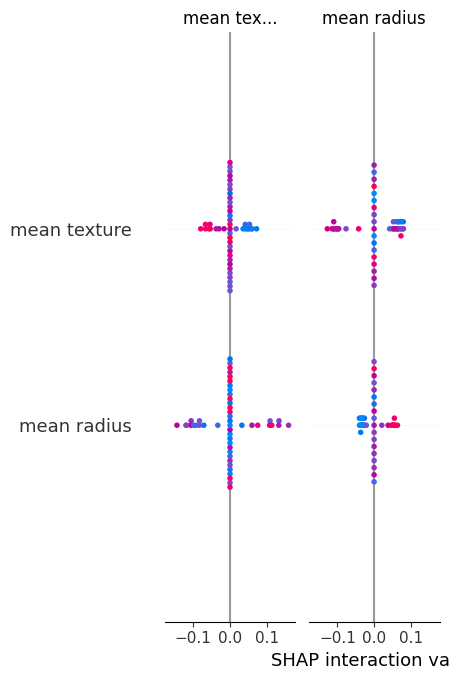


========== XGBoost ==========


Training XGBoost...

Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Generating SHAP explanations...

SHAP shape: (50, 30)
Feature shape: (50, 30)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:53:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


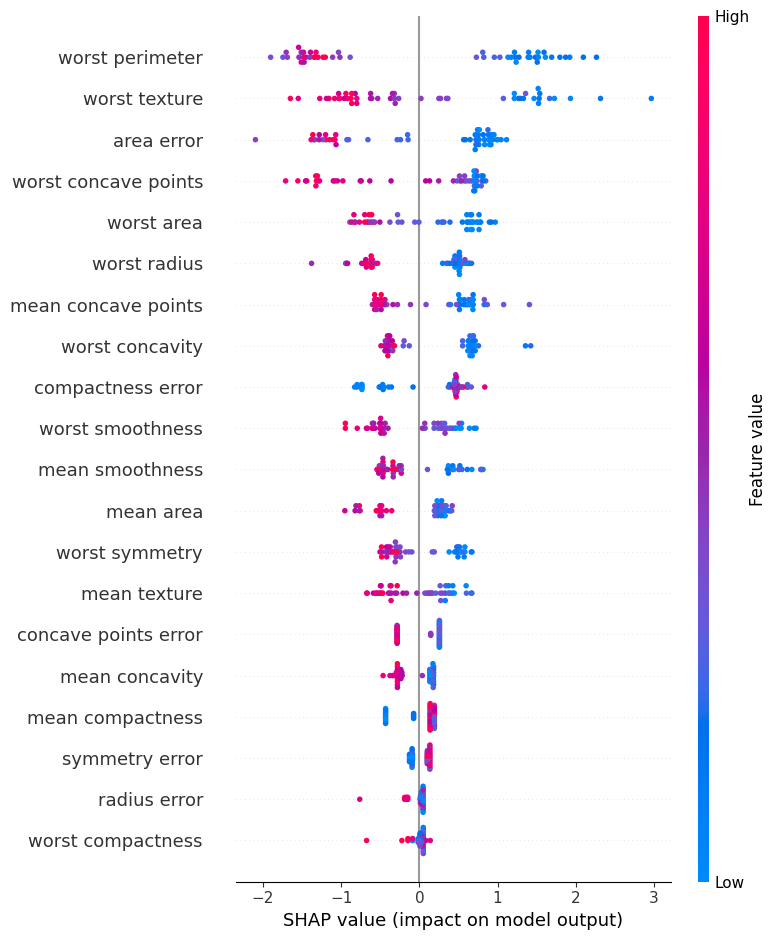


========== DecisionTree ==========


Training DecisionTree...

Accuracy: 0.8947368421052632
              precision    recall  f1-score   support

           0       0.81      0.93      0.87        42
           1       0.95      0.88      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.90      0.89       114
weighted avg       0.90      0.89      0.90       114


Generating SHAP explanations...

SHAP shape: (50, 30, 2)
Feature shape: (50, 30)


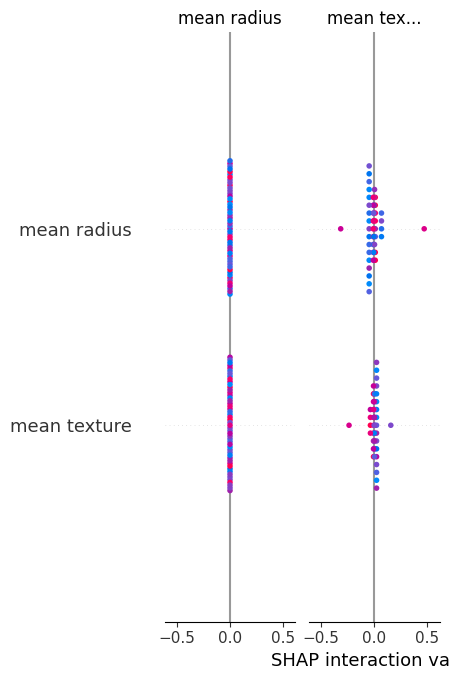

In [ ]:
models = ["RandomForest", "SVM", "XGBoost", "DecisionTree"]

for m in models:
    print(f"\n========== {m} ==========\n")
    model = train_and_evaluate(m)
    explain_with_shap(model, m)

## Full Evaluation



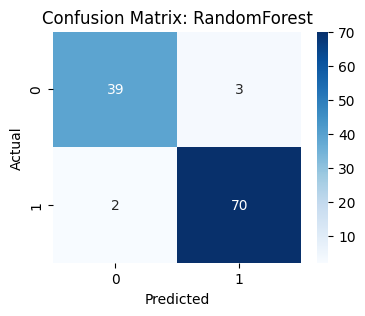

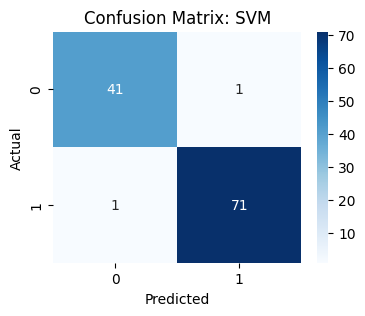

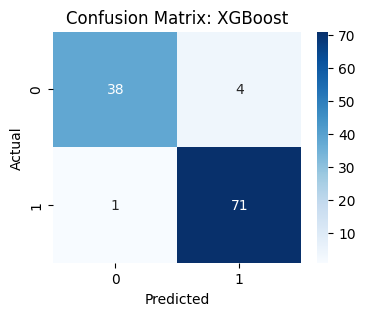

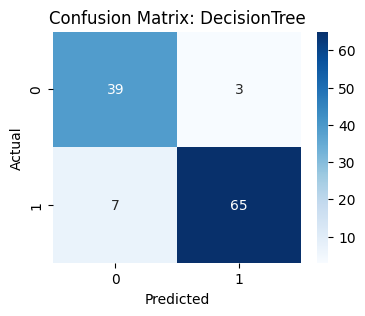

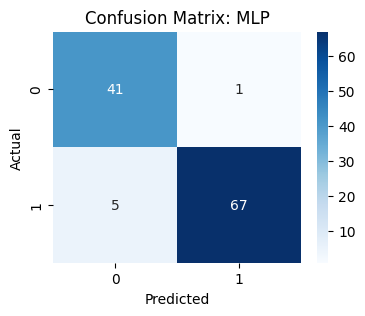

In [ ]:
for model_name in models_list:
    current_model = trained_models[model_name]
    preds, _ = get_predictions(current_model, model_name, X_test_scaled)

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:

def get_predictions(model, model_name):
    if model_name == "MLP":
        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(
                model(torch.FloatTensor(X_test_scaled))
            ).numpy().flatten()

        preds = (probs > 0.5).astype(int)
    else:
        probs = model.predict_proba(X_test_scaled)[:, 1]
        preds = model.predict(X_test_scaled)

    return preds, probs

In [ ]:
def evaluate_model(model, model_name):
    preds, probs = get_predictions(model, model_name)

    # Accuracy
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    print(f"\nModel: {model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC Score: {auc:.4f}\n")
    print(classification_report(y_test, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.show()

    return fpr, tpr, auc

In [ ]:
def compare_models(models_list):
    plt.figure(figsize=(8,6))

    for model_name in models_list:
        print(f"\nTraining {model_name}...")

        if model_name == "MLP":
            model, history = train_mlp(
                X_train_scaled,
                y_train,
                X_test_scaled,
                y_test
            )
        else:
            model = get_model(model_name)
            model.fit(X_train_scaled, y_train)

        preds, probs = get_predictions(model, model_name)

        fpr, tpr, _ = roc_curve(y_test, probs)
        auc = roc_auc_score(y_test, probs)

        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison - All Models")
    plt.legend()
    plt.show()

### 10.4 Run single-model evaluation


Model: RandomForest
Accuracy: 0.9561
AUC Score: 0.9939

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



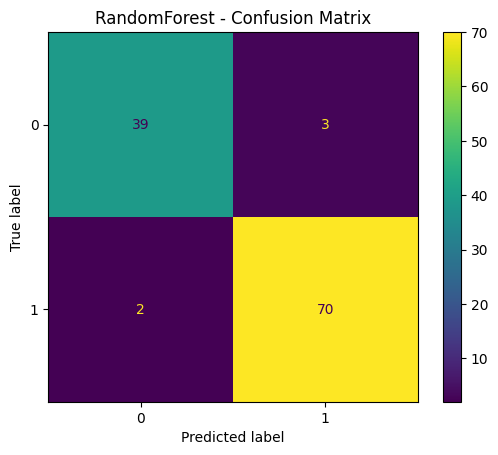

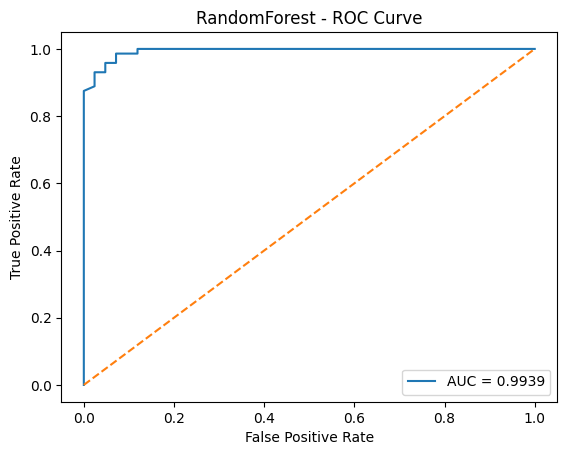

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.02380952, 0.02380952,
        0.02380952, 0.04761905, 0.04761905, 0.07142857, 0.07142857,
        0.11904762, 0.11904762, 0.23809524, 0.30952381, 0.4047619 ,
        0.45238095, 1.        ]),
 array([0.        , 0.33333333, 0.47222222, 0.56944444, 0.63888889,
        0.68055556, 0.70833333, 0.73611111, 0.75      , 0.80555556,
        0.81944444, 0.84722222, 0.875     , 0.88888889, 0.90277778,
        0.93055556, 0.93055556, 0.95833333, 0.95833333, 0.98611111,
        0.98611111, 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        ]),
 np.float64(0.9938822751322751))

In [ ]:
#Sigle model
model_name = "RandomForest"

if model_name == "MLP":
    model = train_mlp(
        X_train_scaled, y_train,
        X_test_scaled, y_test
    )
else:
    model = get_model(model_name)
    model.fit(X_train_scaled, y_train)

evaluate_model(model, model_name)

### Run full ROC comparison


Training RandomForest...

Training SVM...

Training XGBoost...

Training DecisionTree...

Training MLP...
Epoch 1/200
Training Loss: 0.6892
Validation Loss: 0.6820
Accuracy: 0.6404, ROC-AUC: 0.7249
Learning Rate: 0.001000
--------------------
Epoch 2/200
Training Loss: 0.6768
Validation Loss: 0.6704
Accuracy: 0.7544, ROC-AUC: 0.8396
Learning Rate: 0.001000
--------------------
Epoch 3/200
Training Loss: 0.6645
Validation Loss: 0.6587
Accuracy: 0.8333, ROC-AUC: 0.9130
Learning Rate: 0.001000
--------------------
Epoch 4/200
Training Loss: 0.6522
Validation Loss: 0.6473
Accuracy: 0.8509, ROC-AUC: 0.9418
Learning Rate: 0.001000
--------------------
Epoch 5/200
Training Loss: 0.6400
Validation Loss: 0.6360
Accuracy: 0.8860, ROC-AUC: 0.9534
Learning Rate: 0.001000
--------------------
Epoch 6/200
Training Loss: 0.6278
Validation Loss: 0.6248
Accuracy: 0.8947, ROC-AUC: 0.9587
Learning Rate: 0.001000
--------------------
Epoch 7/200
Training Loss: 0.6156
Validation Loss: 0.6135
Accuracy: 0.8

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:56:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Epoch 22/200
Training Loss: 0.4135
Validation Loss: 0.4236
Accuracy: 0.9386, ROC-AUC: 0.9808
Learning Rate: 0.001000
--------------------
Epoch 23/200
Training Loss: 0.3990
Validation Loss: 0.4100
Accuracy: 0.9386, ROC-AUC: 0.9808
Learning Rate: 0.001000
--------------------
Epoch 24/200
Training Loss: 0.3846
Validation Loss: 0.3966
Accuracy: 0.9386, ROC-AUC: 0.9815
Learning Rate: 0.001000
--------------------
Epoch 25/200
Training Loss: 0.3704
Validation Loss: 0.3833
Accuracy: 0.9386, ROC-AUC: 0.9821
Learning Rate: 0.001000
--------------------
Epoch 26/200
Training Loss: 0.3564
Validation Loss: 0.3702
Accuracy: 0.9386, ROC-AUC: 0.9825
Learning Rate: 0.001000
--------------------
Epoch 27/200
Training Loss: 0.3426
Validation Loss: 0.3573
Accuracy: 0.9386, ROC-AUC: 0.9828
Learning Rate: 0.001000
--------------------
Epoch 28/200
Training Loss: 0.3291
Validation Loss: 0.3446
Accuracy: 0.9386, ROC-AUC: 0.9835
Learning Rate: 0.001000
--------------------
Epoch 29/200
Training Loss: 0.3159

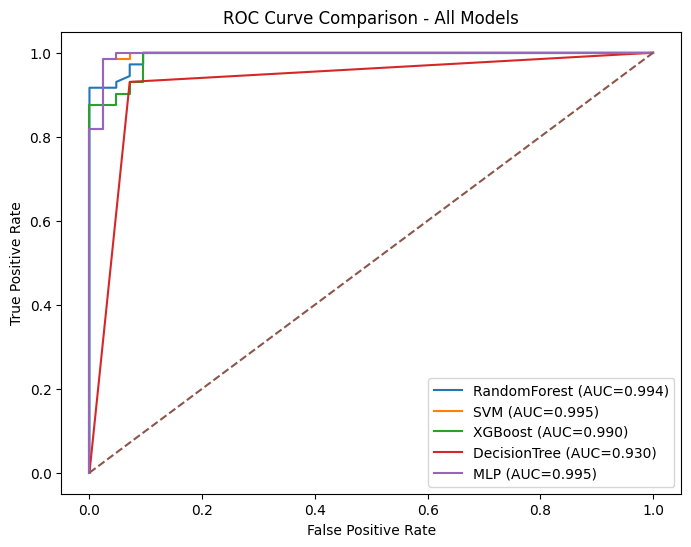

In [ ]:
models_to_compare = [
    "RandomForest",
    "SVM",
    "XGBoost",
    "DecisionTree",
    "MLP"
]

compare_models(models_to_compare)

## SHAP Feature Importance — Cross-Model Analysis




In [ ]:
#Compute with SHAP with model
import shap
import numpy as np
import pandas as pd
import torch

def compute_shap_importance(model, model_name, X_train_scaled, X_test_scaled, feature_names=None):
    """
    Compute SHAP importance safely.
    feature_names: list of strings with length equal to X_test_scaled.shape[1]
    """
    import numpy as np
    import pandas as pd
    import shap
    import torch

    print(f"\nComputing SHAP for {model_name}...")

    X_background = X_train_scaled[:100]
    X_sample = X_test_scaled[:50]

    shap_values = None

    if model_name == "MLP":
        model.eval()
        explainer = shap.DeepExplainer(model, torch.FloatTensor(X_background))
        shap_values = explainer.shap_values(torch.FloatTensor(X_sample))
        if isinstance(shap_values, list):
            shap_values = shap_values[0]
        if torch.is_tensor(shap_values):
            shap_values = shap_values.detach().numpy()

    elif model_name in ["RandomForest", "DecisionTree", "XGBoost"]:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # class 1
        shap_values = np.array(shap_values)
        if shap_values.ndim == 3:
            shap_values = shap_values[1]

    else:  # SVM
        explainer = shap.KernelExplainer(model.predict_proba, X_background)
        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        shap_values = np.array(shap_values)
        if shap_values.ndim == 3:
            shap_values = shap_values[1]

    # Ensure we have feature_names list that matches number of features
    n_features = shap_values.shape[1]
    if feature_names is None or len(feature_names) != n_features:
        feature_names = [f"Feature_{i}" for i in range(n_features)]

    # Mean absolute importance
    importance = np.abs(shap_values).mean(axis=0)

    return pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort_values("importance", ascending=False)

### Train all models and collect SHAP results

In [ ]:
# List of models
models_list = ["RandomForest", "SVM", "XGBoost", "DecisionTree", "MLP"]

shap_results = {}
trained_models = {}

for model_name in models_list:
    print(f"\nTraining {model_name}...")

    if model_name == "MLP":
        model, _ = train_mlp(X_train_scaled, y_train, X_test_scaled, y_test)
    else:
        model = get_model(model_name)
        model.fit(X_train_scaled, y_train)

    trained_models[model_name] = model
    shap_results[model_name] = compute_shap_importance(
        model, model_name, X_train_scaled, X_test_scaled, X.columns
    )

# Display top 5 features per model
for name, df in shap_results.items():
    print(f"\n{name} - Top 5 Features:")
    display(df.head())

In [ ]:
def compute_shap_importance(model, model_name, X_train_scaled, X_test_scaled, feature_names=None):
    """
    Compute SHAP feature importance safely for MLP, SVM, RF, DT, XGBoost.
    Returns a DataFrame sorted by mean absolute SHAP importance.
    """
    import shap
    import torch
    import numpy as np
    import pandas as pd

    X_background = X_train_scaled[:100]
    X_sample = X_test_scaled[:50]

    shap_values = None

    if model_name == "MLP":
        model.eval()
        explainer = shap.DeepExplainer(model, torch.FloatTensor(X_background))
        shap_values = explainer.shap_values(torch.FloatTensor(X_sample))
        if isinstance(shap_values, list):
            shap_values = shap_values[0]
        if torch.is_tensor(shap_values):
            shap_values = shap_values.detach().numpy()

    elif model_name in ["RandomForest", "DecisionTree", "XGBoost"]:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # class 1 for binary
        shap_values = np.array(shap_values)
        # flatten 3D if exists
        if shap_values.ndim == 3:
            shap_values = shap_values[:, 0, :]  # (n_samples, n_features)

    else:  # SVM
        explainer = shap.KernelExplainer(model.predict_proba, X_background)
        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        shap_values = np.array(shap_values)
        if shap_values.ndim == 3:
            shap_values = shap_values[:, 0, :]

    # Compute mean absolute importance
    importance = np.abs(shap_values).mean(axis=0).flatten()

    # Ensure feature_names matches
    n_features = shap_values.shape[1]
    if feature_names is None or len(feature_names) != n_features:
        feature_names = [f"Feature_{i}" for i in range(n_features)]

    return pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort_values("importance", ascending=False)

### 11.4 Display top features




In [ ]:
shap_results[model_name] = compute_shap_importance(
    trained_models[model_name],
    model_name,
    X_train_scaled,
    X_test_scaled,
    feature_names=X.columns.tolist()  # optional, will auto-fix if mismatch
)
for name, df in shap_results.items():
    print(f"\n{name} - Top 5 Features:")
    display(df.head())


RandomForest - Top 5 Features:


,feature,importance
0,Feature_0,0.01282
1,Feature_1,0.01282



SVM - Top 5 Features:


,feature,importance
1,Feature_1,0.012897
0,Feature_0,0.012897



XGBoost - Top 5 Features:


,feature,importance
22,worst perimeter,1.406645
21,worst texture,1.027178
13,area error,0.916157
27,worst concave points,0.817780
23,worst area,0.605698



DecisionTree - Top 5 Features:


,feature,importance
0,Feature_0,0.012603
1,Feature_1,0.012603



MLP - Top 5 Features:


,feature,importance
21,worst texture,0.803173
20,worst radius,0.632189
3,mean area,0.582734
24,worst smoothness,0.562644
1,mean texture,0.531386


### SHAP importance heatmap



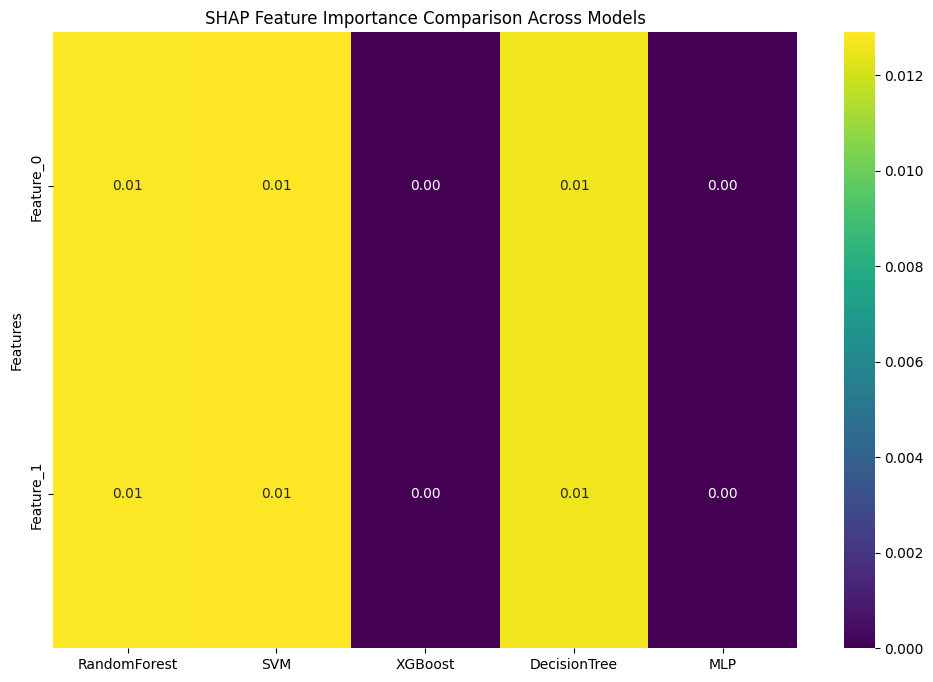

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Build importance matrix
importance_matrix = pd.DataFrame()
for name, df in shap_results.items():
    importance_matrix[name] = df.set_index("feature")["importance"]

importance_matrix = importance_matrix.fillna(0)

plt.figure(figsize=(12,8))
sns.heatmap(importance_matrix, cmap="viridis", annot=True, fmt=".2f")
plt.title("SHAP Feature Importance Comparison Across Models")
plt.ylabel("Features")
plt.show()

## Final Model Rankings




In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

def get_predictions(model, model_name, X_test_scaled):
    """
    Get predictions and probabilities for all models.
    Returns preds (0/1) and probs (for ROC-AUC)
    """
    import torch
    import numpy as np

    if model_name == "MLP":
        model.eval()
        with torch.no_grad():
            # ONLY use X_test_scaled here
            X_tensor = torch.FloatTensor(X_test_scaled)
            probs = torch.sigmoid(model(X_tensor)).numpy()
            if probs.ndim > 1:
                probs = probs.flatten()  # flatten to 1D
            preds = (probs > 0.5).astype(int)
    else:
        preds = model.predict(X_test_scaled)
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test_scaled)[:,1]
        else:
            probs = preds
    return preds, probs

# Compute metrics
metrics_table = []

for model_name in models_list:
    model = trained_models[model_name]
    preds, probs = get_predictions(model, model_name, X_test_scaled)  # pass ONLY X_test_scaled

    metrics_table.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, preds),
        "AUC": roc_auc_score(y_test, probs),
        "F1": f1_score(y_test, preds)
    })

#metrics_df = pd.DataFrame(metrics_table).set_index("Model")
#display(metrics_df)

metrics_df = pd.DataFrame(metrics_table).set_index("Model")
ranking = metrics_df.rank(ascending=False)
print("\nModel Performance Metrics:")
display(metrics_df)
print("\nModel Ranking (Lower Rank = Better):")
display(ranking)
print("\nOverall Score (Mean Rank):")
display(ranking.mean(axis=1).sort_values())

,Accuracy,AUC,F1
Model,,,
RandomForest,0.956140,0.992890,0.965517
SVM,0.982456,0.995040,0.986111
XGBoost,0.956140,0.990079,0.965986
DecisionTree,0.912281,0.915675,0.928571
MLP,0.947368,0.993386,0.957143



Model Performance Metrics:


,Accuracy,AUC,F1
Model,,,
RandomForest,0.956140,0.992890,0.965517
SVM,0.982456,0.995040,0.986111
XGBoost,0.956140,0.990079,0.965986
DecisionTree,0.912281,0.915675,0.928571
MLP,0.947368,0.993386,0.957143



Model Ranking (Lower Rank = Better):


,Accuracy,AUC,F1
Model,,,
RandomForest,2.5,3.0,3.0
SVM,1.0,1.0,1.0
XGBoost,2.5,4.0,2.0
DecisionTree,5.0,5.0,5.0
MLP,4.0,2.0,4.0



Overall Score (Mean Rank):


,0
Model,
SVM,1.000000
RandomForest,2.833333
XGBoost,2.833333
MLP,3.333333
DecisionTree,5.000000


## Individual Patient Explainability (Waterfall Plot)


In [ ]:
import shap

def plot_patient_shap(model, model_name, X_sample_scaled, patient_index, feature_names):
    """
    Generate a SHAP waterfall plot for a single patient
    """
    X_patient = X_sample_scaled[patient_index:patient_index+1]

    # Compute SHAP values
    if model_name == "MLP":
        model.eval()
        explainer = shap.DeepExplainer(model, torch.FloatTensor(X_sample_scaled[:100]))
        shap_values = explainer.shap_values(torch.FloatTensor(X_patient))[0].flatten()
        base_value = explainer.expected_value[0]
    elif model_name in ["RandomForest", "DecisionTree", "XGBoost"]:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_patient)
        if isinstance(shap_values, list):
            shap_values = shap_values[1].flatten()
            base_value = explainer.expected_value[1]
        else:
            shap_values = shap_values.flatten()
            base_value = explainer.expected_value
    else:  # SVM
        explainer = shap.KernelExplainer(model.predict_proba, X_sample_scaled[:100])
        shap_values = explainer.shap_values(X_patient)[1].flatten()
        base_value = explainer.expected_value[1]

    # Use SHAP Explanation object for waterfall
    shap_exp = shap.Explanation(values=shap_values,
                                base_values=base_value,
                                feature_names=feature_names,
                                data=X_patient)

    print(f"Patient Index: {patient_index}")
    shap.plots.waterfall(shap_exp)